In [1]:
pip install xgboost scikit-learn pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("waterwatch_dataset.csv")
print(df.shape)
print(df.head())



(2160, 10)
         date ward_id  supply_hours  pressure  demand  supply  complaints  \
0  01/01/2024     W01           8.8      40.2   19.17   14.06        2.56   
1  02/01/2024     W01           8.3      36.6   19.17   13.26        2.96   
2  03/01/2024     W01           9.0      39.2   19.17   14.38        2.40   
3  04/01/2024     W01           7.8      35.3   19.17   12.46        3.36   
4  05/01/2024     W01           9.2      32.6   19.17   14.70        2.24   

   pipe_breaks  tanker  scarcity  
0            1      51         0  
1            0      59         1  
2            1      47         0  
3            1      67         1  
4            1      44         0  


In [8]:
features = [
    "supply_hours",
    "pressure",
    "demand",
    "supply",
    "complaints",
    "pipe_breaks",
]

target = "scarcity"

In [7]:
print(df.columns.tolist())

['date', 'ward_id', 'supply_hours', 'pressure', 'demand', 'supply', 'complaints', 'pipe_breaks', 'tanker', 'scarcity']


In [9]:
X = df[features]
y = df[target]

print(f"Features: {X.shape[1]}")
print(f"Scarcity cases: {y.sum()} / {len(y)}")

Features: 6
Scarcity cases: 826 / 2160


In [10]:
df = df.sort_values(["ward_id", "date"]).reset_index(drop=True)

for col in ["supply_hours", "complaints", "pipe_breaks"]:
    if col in df.columns:
        df[f"{col}_7day_avg"] = (
            df.groupby("ward_id")[col]
            .transform(lambda x: x.rolling(7, min_periods=1).mean())
            .round(2)
        )


In [11]:
df["demand_supply_gap"] = (df["demand"] - df["supply"]).round(2)

print("✅ Rolling features added!")

✅ Rolling features added!


In [12]:
features = [
    "supply_hours",
    "pressure",
    "demand",
    "supply",
    "complaints",
    "pipe_breaks",
    "demand_supply_gap",
    "supply_hours_7day_avg",
    "complaints_7day_avg",
    "pipe_breaks_7day_avg"
]
features = [f for f in features if f in df.columns]
target = "scarcity"

X = df[features]
y = df[target]

print(f"\n✅ Features used: {features}")
print(f"Total features: {len(features)}")
print(f"Scarcity cases: {y.sum()} / {len(y)}")


✅ Features used: ['supply_hours', 'pressure', 'demand', 'supply', 'complaints', 'pipe_breaks', 'demand_supply_gap', 'supply_hours_7day_avg', 'complaints_7day_avg', 'pipe_breaks_7day_avg']
Total features: 10
Scarcity cases: 826 / 2160


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Train: {X_train.shape}, Test: {X_test.shape}")


✅ Train: (1728, 10), Test: (432, 10)


In [14]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)
print("\n✅ Model trained successfully!")


✅ Model trained successfully!



📊 MODEL PERFORMANCE:
              precision    recall  f1-score   support

 No Scarcity       0.99      1.00      0.99       267
    Scarcity       1.00      0.98      0.99       165

    accuracy                           0.99       432
   macro avg       0.99      0.99      0.99       432
weighted avg       0.99      0.99      0.99       432



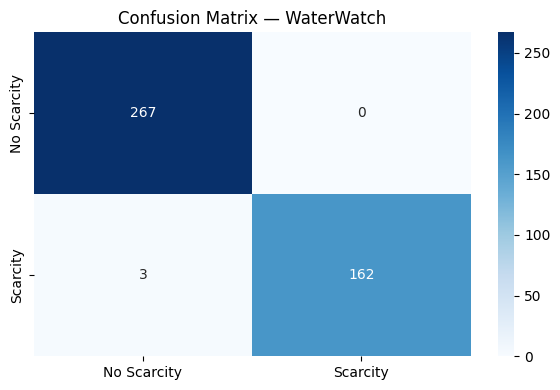

✅ Confusion matrix saved!


In [15]:
y_pred = model.predict(X_test)

print("\n📊 MODEL PERFORMANCE:")
print(classification_report(
    y_test, y_pred,
    target_names=["No Scarcity", "Scarcity"]
))

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Scarcity", "Scarcity"],
            yticklabels=["No Scarcity", "Scarcity"])
plt.title("Confusion Matrix — WaterWatch")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
print("✅ Confusion matrix saved!")

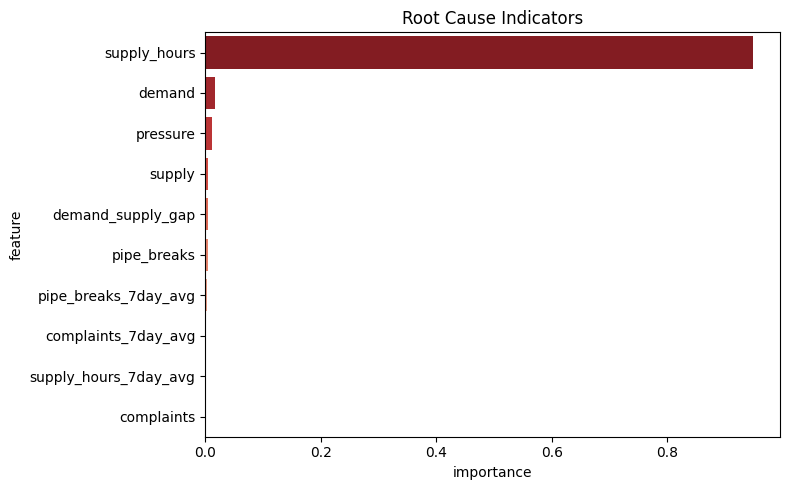

                 feature  importance
0           supply_hours    0.947442
2                 demand    0.017440
1               pressure    0.012621
3                 supply    0.005702
6      demand_supply_gap    0.005702
5            pipe_breaks    0.005505
9   pipe_breaks_7day_avg    0.002373
8    complaints_7day_avg    0.001855
7  supply_hours_7day_avg    0.001361
4             complaints    0.000000


In [17]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="importance",
            y="feature", palette="Reds_r")
plt.title("Root Cause Indicators")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

print(importance)

In [18]:
latest = df.sort_values("date").groupby("ward_id").tail(7)
ward_avg = latest.groupby("ward_id")[features].mean().reset_index()

# Risk score 0-100
ward_avg["risk_score"] = model.predict_proba(
    ward_avg[features]
)[:, 1] * 100

ward_avg["risk_score"] = ward_avg["risk_score"].round(1)

# Risk level
ward_avg["risk_level"] = pd.cut(
    ward_avg["risk_score"],
    bins=[0, 40, 70, 100],
    labels=["🟢 Low", "🟡 Medium", "🔴 High"]
)

print(ward_avg[["ward_id", "risk_score", "risk_level"]])

   ward_id  risk_score risk_level
0      W01    0.100000      🟢 Low
1      W02    0.000000        NaN
2      W03   99.900002     🔴 High
3      W04   99.900002     🔴 High
4      W05    0.000000        NaN
5      W06    0.100000      🟢 Low
6      W07   99.900002     🔴 High
7      W08    0.000000        NaN
8      W09    0.000000        NaN
9      W10   99.900002     🔴 High
10     W11    0.000000        NaN
11     W12   99.800003     🔴 High


In [19]:
def recommend_tankers(row):
    gap = row["demand"] - row["supply"]
    risk = row["risk_score"]
    base = max(0, int(gap * 8))
    if risk > 70:
        return base + 3
    elif risk > 40:
        return base + 1
    return base

ward_avg["tankers_needed"] = ward_avg.apply(
    recommend_tankers, axis=1
)

print("\n🚰 TANKER PRE-ALLOCATION PLAN:")
print(ward_avg[["ward_id", "risk_score",
                "risk_level", "tankers_needed"]]
      .to_string(index=False))


🚰 TANKER PRE-ALLOCATION PLAN:
ward_id  risk_score risk_level  tankers_needed
    W01    0.100000      🟢 Low              42
    W02    0.000000        NaN              21
    W03   99.900002     🔴 High              33
    W04   99.900002     🔴 High              81
    W05    0.000000        NaN              21
    W06    0.100000      🟢 Low              16
    W07   99.900002     🔴 High              66
    W08    0.000000        NaN              21
    W09    0.000000        NaN              27
    W10   99.900002     🔴 High              43
    W11    0.000000        NaN              33
    W12   99.800003     🔴 High              28


In [20]:
ward_avg.to_csv("ward_risk_predictions.csv", index=False)
importance.to_csv("feature_importance.csv", index=False)

print("✅ ward_risk_predictions.csv saved!")
print("✅ feature_importance.csv saved!")


✅ ward_risk_predictions.csv saved!
✅ feature_importance.csv saved!
